In [ ]:
# notebook to check the correlations between CRE contacts and predicted activity

In [68]:
# import packages
import pandas as pd
import numpy as np
import pybedtools
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import os
import requests
from collections import Counter
from scipy import stats
from tqdm import tqdm
from statsmodels.stats.multitest import multipletests

In [2]:
# open CRISPR links data
crispr_gene_links = pd.read_csv('../raw_data/V4-hg38.Gene-Links.CRISPR.txt', sep = '\t', header = None)

In [3]:
# filter for K562
k562_crispr_links = crispr_gene_links[(crispr_gene_links[7] == 'K562') & (crispr_gene_links[9] < 0.05)]
# make a dictionary for annotating predictions
k562_crispri_link_dict = dict(zip(k562_crispr_links[0], [1 for i in range(len(k562_crispr_links))]))

In [4]:
# open BED files for annotating predictions
# ENCODE dELS - cell type agnostic
dELS_bed = pybedtools.BedTool('../processed_data/GRCh38-dELS-only.bed')
# ENCODE cCRE - K562
k562_cCRE = pybedtools.BedTool('../raw_data/ENCFF414OGC_ENCFF806YEZ_ENCFF849TDM_ENCFF736UDR_K562_cCRE.bed').to_dataframe()
# ENCODE cCRE - HepG2
hepg2_cCRE = pybedtools.BedTool('../raw_data/ENCFF546MZK_ENCFF732PJK_ENCFF795ONN_ENCFF357NFO_HepG2_cCRE.bed')
# ENCODE cCRE - SKNSH
sknsh_cCRE = pybedtools.BedTool('../raw_data/ENCFF280RMA_ENCFF651WOM_ENCFF262UEH_ENCFF850MLW_SKNSH_cCRE.bed')

In [5]:
# make dictionaries for annotating a cell type specific cre
k562_dELS_dict = dict(zip(k562_cCRE[k562_cCRE['blockCount'] == 'dELS']['name'], [1 for i in range(len(k562_cCRE[k562_cCRE['blockCount'] == 'dELS']))]))

In [6]:
# open enhancer level averaged predictions #
all_mean_preds = pd.read_csv('../processed_data/all_dELS_sat_mut_groupby_mean.tsv',
                             sep = '\t')

In [9]:
# add links and cCREs to DF
# K562 dELS
all_mean_preds.loc[:, 'k562_dELS'] = [k562_dELS_dict.get(i) if i in k562_dELS_dict.keys() else 0 for i in all_mean_preds['id']]
# k562 CRISPRi link
all_mean_preds.loc[:, 'k562_crispri_link'] = [k562_crispri_link_dict.get(i) if i in k562_crispri_link_dict.keys() else 0 for i in all_mean_preds['id']]
# make an annotated column for plotting the three together
all_mean_preds.loc[:, 'k_linked_cre'] = ['K562 dELS' if matched == 1 else 'CRISPRi Linked' if linked == 1 else 'Agnostic dELS' for matched, linked in zip(all_mean_preds['k562_dELS'], all_mean_preds['k562_crispri_link'])]

In [13]:
# open random sequence predictions
# define function to reformat predictions #
def vcf2df (pred_df):
    # make lists of preds for new column
    # k562
    k_ref = []
    k_alt = []
    k_skew = []
    # hepg2
    h_ref = []
    h_alt = []
    h_skew = []
    # sknsh
    s_ref = []
    s_alt = []
    s_skew = []
    # parse predictions in 'INFO' column
    for i in tqdm(pred_df['INFO']):
        all_preds = i.split(';')
        # k562
        k_ref.append(float(all_preds[0].split('=')[-1]))
        k_alt.append(float(all_preds[3].split('=')[-1]))
        k_skew.append(float(all_preds[6].split('=')[-1]))
        # hepg2
        h_ref.append(float(all_preds[1].split('=')[-1]))
        h_alt.append(float(all_preds[4].split('=')[-1]))
        h_skew.append(float(all_preds[7].split('=')[-1]))
        # sknsh
        s_ref.append(float(all_preds[2].split('=')[-1]))
        s_alt.append(float(all_preds[5].split('=')[-1]))
        s_skew.append(float(all_preds[8].split('=')[-1]))
    
    df = pd.DataFrame({'chrom' : pred_df['chrom'],
                       'pos' : pred_df['pos'],
                       'id' : pred_df['id'],
                       'ref' : pred_df['ref'],
                       'alt' : pred_df['alt'],
                       'k562_ref_pred' : k_ref,
                       'k562_alt_pred' : k_alt,
                       'k562_skew_pred' : k_skew,
                       'hepg2_ref_pred' : h_ref,
                       'hepg2_alt_pred' : h_alt,
                       'hepg2_skew_pred' : h_skew,
                       'sknsh_ref_pred' : s_ref,
                       'sknsh_alt_pred' : s_alt,
                       'sknsh_skew_pred' : s_skew})
    return df
# iterate through all predictions and concatenate #
random_sequence_preds = pd.concat([vcf2df(pd.read_csv(f'../mpac_preds/random_interval_preds/{i}', sep = '\t')) for i in tqdm([i for i in os.listdir('../mpac_preds/random_interval_preds/') if i.endswith('.vcf')])])

100%|██████████| 22/22 [00:08<00:00,  2.46it/s]


In [14]:
# add annotation to random sequence DFs
random_sequence_preds.loc[:, 'annotation'] = ['Non-cCRE' for i in range(len(random_sequence_preds))]

In [100]:
# define a function for plotting CRISPRi link activity
def CRISPRviolin_plot (mean_preds, random_preds, outpath):
    # define palette based on cell type #
    # K562 #
    k_pal = {'dELS' : 'gray',
             'K562 dELS' : '#00A79D',
             'K562 CRISPRi Linked' : '#0054A7',
             'Non-cCRE' : 'aliceblue'}
    # Reformat DFs
    # dELS (non-matched)
    dELS_all = mean_preds.filter(['id', 'k562_ref_pred']).copy()
    dELS_all.loc[:, 'annotation'] = ['dELS' for i in range(len(dELS_all))]
    # K562 dELS
    dELS_tmp = mean_preds.filter(['id', 'k562_ref_pred', 'k562_dELS']).copy()
    k_dELS_preds = dELS_tmp[dELS_tmp['k562_dELS'] == 1].copy()
    # add annotations
    k_dELS_preds.loc[:, 'annotation'] = ['K562 dELS' for i in range(len(k_dELS_preds))]
    # K562 CRISPRi linked
    CRISPRi_tmp = mean_preds.filter(['id', 'k562_ref_pred', 'k562_crispri_link']).copy()
    k_CRISPRi_preds = CRISPRi_tmp[CRISPRi_tmp['k562_crispri_link'] == 1].copy()
    # add annotations
    k_CRISPRi_preds.loc[:,'annotation'] = ['K562 CRISPRi Linked' for i in range(len(k_CRISPRi_preds))]
    # combine with non-cCRE sequences
    k2plot = pd.concat([
        dELS_all.filter(['k562_ref_pred', 'annotation']),
        k_dELS_preds.filter(['k562_ref_pred', 'annotation']),
        k_CRISPRi_preds.filter(['k562_ref_pred', 'annotation']),
        #random_preds.filter(['k562_ref_pred', 'annotation'])
    ])
    # define function for running ANOVAs
    def anova_test (plotdf, cell_type):
        # split into groups
        # dELS
        dELS = plotdf[plotdf['annotation'] == 'dELS'][f'{cell_type}_ref_pred']
        # k562 dELS
        k_dELS = plotdf[plotdf['annotation'] == 'K562 dELS'][f'{cell_type}_ref_pred']
        ## non-ccre
        #nonCRE = plotdf[plotdf['annotation'] == 'Non-cCRE'][f'{cell_type}_ref_pred']
        # crispri linked
        CRISPRi_linked = plotdf[plotdf['annotation'] == 'K562 CRISPRi Linked'][f'{cell_type}_ref_pred']
        # perform ANOVA and return f_stat and pvalue
        f_stat, p_value = stats.f_oneway(dELS, k_dELS, CRISPRi_linked)
        return f_stat, p_value, [dELS, k_dELS, CRISPRi_linked];

    # perform ANOVA for K562
    k_fStat, k_pVal, kGroups = anova_test(k2plot, 'k562')
    print('K562 ANOVA')
    print(f"F-statistic K562: {k_fStat}")
    print(f"P-value K562: {k_pVal}")
    # define function for performing tests for each cell type
    def performTtests (groupList, cell_type):
        # make a list of comparisons
        comps = [
            ('dELS', 'K562 dELS', stats.ttest_ind(groupList[0], groupList[1])), # dELS vs. K562 dELS
            ('dELS', 'K562 CRISPRi Linked', stats.ttest_ind(groupList[0], groupList[-1])), # dELS vs. CRISPRi linked dELS
            ('K562 dELS', 'K562 CRISPRi Linked', stats.ttest_ind(groupList[1], groupList[-1])), # K562 dELS vs. CRISPRi linked dELS
        ]
        # get p-values
        p_values = [comp[2].pvalue for comp in comps]
        # do benjamini-hochberg correction
        reject, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh')
        # make a dictionary for annotating plots
        dict4annotation = {
            'dELS_kdELS' : {
                'raw_p' : comps[0][2].pvalue,
                'adj_p' : p_adjusted[0],
                't_stat' : comps[0][2].statistic
            },
            'dELS_CRISPRi' : {
                'raw_p' : comps[1][2].pvalue,
                'adj_p' : p_adjusted[1],
                't_stat' : comps[1][2].statistic
            },
            'k_dELS_CRISPRi' : {
                'raw_p' : comps[2][2].pvalue,
                'adj_p' : p_adjusted[2],
                't_stat' : comps[2][2].statistic
            }
        }
        return dict4annotation
    # perform multiple t-tests with correction
    # K562
    k_testDict = performTtests(kGroups, 'k562')
        # plot mean reference activity for called cCREs vs. Low-DNase regions #
    f = plt.figure(figsize = (2,3), dpi = 300)
    #gs = f.add_gridspec(1,3)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    # plot k562 #
    with sns.axes_style('white'):
        ax01 = f.add_subplot()
        ax01.set_box_aspect(1)
        sns.violinplot(data=k2plot,
                    x='annotation',
                    y='k562_ref_pred',
                    hue='annotation',
                    linewidth=0.5,
                    palette=k_pal)
        # add 'activity' line
        plt.hlines(y=1, xmin= -0.5, xmax=2.5, linestyle='dashed', alpha=0.25, linewidth=0.25, color='k')
        # add line for comparison between dELS and K562 dELS
        plt.hlines(y=np.max(k2plot['k562_ref_pred']) * 0.5, xmin=0.1, xmax=0.9, linewidth=0.5, color='k', linestyle='dashed')
        # annotate the pvalue from the t-test for that comparison
        plt.text(x=0.5, 
                 y=np.max(k2plot['k562_ref_pred']) * 0.55, 
                 s=f'p: {k_testDict['dELS_kdELS']['raw_p']}', 
                 horizontalalignment='center', 
                 verticalalignment='center', 
                 fontsize=4)
        # add line for comparison between dELS and CRISPRi Linked
        plt.hlines(y=np.max(k2plot['k562_ref_pred']) * 1.05, xmin=0.1, xmax=1.9, linewidth=0.5, color='k', linestyle='dashed')
        # annotate the pvalue from the t-test for that comparison
        plt.text(x=1, 
                 y=np.max(k2plot['k562_ref_pred']) * 1.1, 
                 s=f'p: {k_testDict['dELS_CRISPRi']['raw_p']:.2e}', 
                 horizontalalignment='center', 
                 verticalalignment='center', 
                 fontsize=4)
        # add line for comparison between K562 dELS and CRISPRi linked dELS
        plt.hlines(y=np.max(k2plot[k2plot['annotation'] == 'K562 CRISPRi Linked']['k562_ref_pred']) * 1.2, xmin=1.1, xmax=1.9, linewidth=0.5, color='k', linestyle='dashed')
        # annotate the pvalue from the t-test for that comparison
        plt.text(x=1.5, 
                 y=np.max(k2plot[k2plot['annotation'] == 'K562 CRISPRi Linked']['k562_ref_pred']) * 1.4, 
                 s=f'p: {k_testDict['k_dELS_CRISPRi']['raw_p']:.2e}', 
                 horizontalalignment='center', 
                 verticalalignment='center', 
                 fontsize=4)
        plt.xticks(fontsize = 4, rotation = 90)
        plt.yticks(fontsize = 6)
        plt.xlabel('')
        plt.ylabel('K562 Ref Pred', fontsize = 4)
        #mpl.title('K562', loc='left', fontsize=6)
    sns.despine()
    plt.savefig(outpath)

K562 ANOVA
F-statistic K562: 28220.18160735365
P-value K562: 0.0


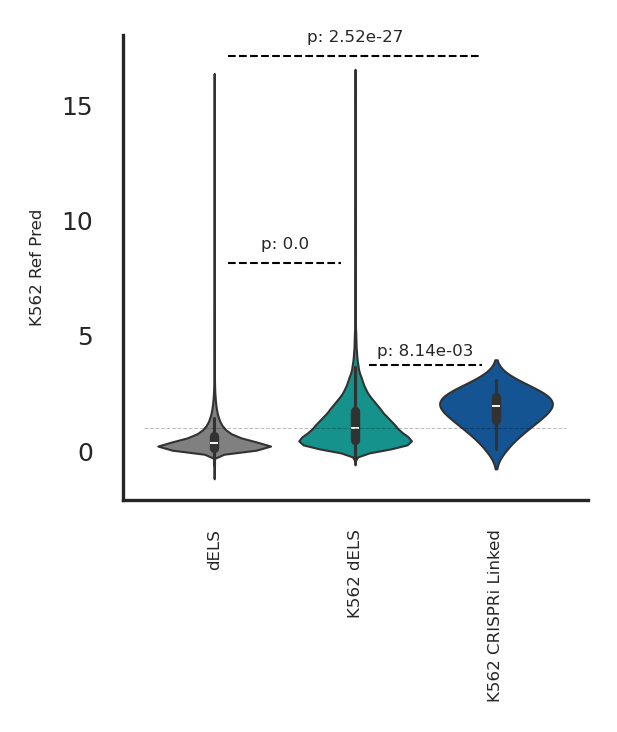

In [101]:
CRISPRviolin_plot(all_mean_preds, random_sequence_preds, '../analyses/figures/K562_CRISPRi_Activity_Violin.pdf')

In [9]:
threeD_chromatin_links = pd.read_csv('../raw_data/V4-hg38.Gene-Links.3D-Chromatin.txt', sep = '\t', header = None)

In [10]:
# filter 3D chromtain data for each cell type
# k562
k562_3D_chromatin = threeD_chromatin_links[threeD_chromatin_links[6] == 'K562'].copy()
# hepg2
hepg2_3D_chromatin = threeD_chromatin_links[threeD_chromatin_links[6] == 'HepG2'].copy()
# sknsh
sknsh_3D_chromatin = threeD_chromatin_links[threeD_chromatin_links[6] == 'SK-N-SH'].copy()

In [11]:
# define a function for generating dictionaries for adding 3D chromatin information to the predictions
def return_3d_dict (cell_chromatin_df, chromatin_feature):
    # filter the df for only the assay of choice
    assay_df = cell_chromatin_df[cell_chromatin_df[4] == chromatin_feature]
    # convert the df to a dictionary for annotating predictions
    assay_dict = dict(zip(
        assay_df[0], # Enhancer ID name
        [1 for i in range(len(assay_df))] # score of hit
    ))
    return assay_dict
# define a function for returning a dictionary with the counts of a 
def return_linkage_counts (cell_chromatin_df, chromatin_feature):
    # filter the df for only the assay of choice
    assay_df = cell_chromatin_df[cell_chromatin_df[4] == chromatin_feature].copy()
    # add a count column for groupby
    assay_df.loc[:, 'count'] = [1 for i in range(len(assay_df))]
    # count linkages by enhancer id
    linkage_groupby = assay_df.filter([0, 'count']).groupby(0).sum()
    # convert that to a dictionary
    n_linkage_dict = dict(zip(
        linkage_groupby.index,
        linkage_groupby['count']
    ))
    return n_linkage_dict
# define a function for returning a list for 
def return_contact_list (preds_df, threeD_dict):
    return [threeD_dict.get(i) if i in threeD_dict.keys() else 0 for i in preds_df['id']]

In [12]:
# make dictionaries for each measure - binary
# k562
k562_rnap2_dict = return_3d_dict(k562_3D_chromatin, 'RNAPII-ChIAPET')
k562_ctcf_dict = return_3d_dict(k562_3D_chromatin, 'CTCF-ChIAPET')
k562_hiC_dict = return_3d_dict(k562_3D_chromatin, 'Intact-HiC')
# hepg2
hepg2_rnap2_dict = return_3d_dict(hepg2_3D_chromatin, 'RNAPII-ChIAPET')
hepg2_ctcf_dict = return_3d_dict(hepg2_3D_chromatin, 'CTCF-ChIAPET')
hepg2_hiC_dict = return_3d_dict(hepg2_3D_chromatin, 'Intact-HiC')
# sknsh
sknsh_rnap2_dict = return_3d_dict(sknsh_3D_chromatin, 'RNAPII-ChIAPET')
sknsh_ctcf_dict = return_3d_dict(sknsh_3D_chromatin, 'CTCF-ChIAPET')
sknsh_hiC_dict = return_3d_dict(sknsh_3D_chromatin, 'Intact-HiC')

In [13]:
# make dictionaries for each measure - n links per enhancer
# k562
k562_rnap2_counts = return_linkage_counts(k562_3D_chromatin, 'RNAPII-ChIAPET')
k562_ctcf_counts = return_linkage_counts(k562_3D_chromatin, 'CTCF-ChIAPET')
k562_hiC_counts = return_linkage_counts(k562_3D_chromatin, 'Intact-HiC')
# hepg2
hepg2_rnap2_counts = return_linkage_counts(hepg2_3D_chromatin, 'RNAPII-ChIAPET')
hepg2_ctcf_counts = return_linkage_counts(hepg2_3D_chromatin, 'CTCF-ChIAPET')
hepg2_hiC_counts = return_linkage_counts(hepg2_3D_chromatin, 'Intact-HiC')
# sknsh
sknsh_rnap2_counts = return_3d_dict(sknsh_3D_chromatin, 'RNAPII-ChIAPET')
sknsh_ctcf_counts = return_3d_dict(sknsh_3D_chromatin, 'CTCF-ChIAPET')
sknsh_hiC_counts = return_3d_dict(sknsh_3D_chromatin, 'Intact-HiC')

In [14]:
# add chromatin annotations to predictions
for dictionary, column in zip(
    [k562_rnap2_dict, k562_ctcf_dict, k562_hiC_dict, k562_rnap2_counts, k562_ctcf_counts, k562_hiC_counts, # K562 
    hepg2_rnap2_dict, hepg2_ctcf_dict, hepg2_hiC_dict, hepg2_rnap2_counts, hepg2_ctcf_counts, hepg2_hiC_counts, # HepG2
    sknsh_rnap2_dict, sknsh_ctcf_dict, sknsh_hiC_dict, sknsh_rnap2_counts, sknsh_ctcf_counts, sknsh_hiC_counts], # SKNSH
    ['k562_rnap2_link', 'k562_ctcf_link', 'k562_hiC_link', 'k562_rnap2_counts', 'k562_ctcf_counts', 'k562_hiC_counts', # K562 columns
    'hepg2_rnap2_link', 'hepg2_ctcf_link', 'hepg2_hiC_link', 'hepg2_rnap2_counts', 'hepg2_ctcf_counts', 'hepg2_hiC_counts', # HepG2 columns
    'sknsh_rnap2_link', 'sknsh_ctcf_link', 'sknsh_hiC_link', 'sknsh_rnap2_counts', 'sknsh_ctcf_counts', 'sknsh_hiC_counts'] # SKNSH columns
):
    all_mean_preds.loc[:, column] = return_contact_list(all_mean_preds, dictionary)    

In [29]:
# add bins for n linkages per cCRE
bins = [0, 1, 2, 5, 7, 10, 15]  # 0 is separate, then ranges
labels = ['0', '1-2', '2-5', '5-7', '7-10', '10-15']
# add k562 bins
#all_mean_preds.loc[:, 'k_rnap2_bin'] = pd.cut(all_mean_preds['k562_rnap2_counts'], bins=bins, labels=labels, right=False, include_lowest=True)
all_mean_preds.loc[:, 'k_ctcf_bin'] = pd.cut(all_mean_preds['k562_ctcf_counts'], bins=bins, labels=labels, right=False, include_lowest=True)
#all_mean_preds.loc[:, 'k_hiC_bin'] = pd.cut(all_mean_preds['k562_hiC_counts'], bins=bins, labels=labels, right=False, include_lowest=True)
# add hepg2 bins
#all_mean_preds.loc[:, 'h_rnap2_bin'] = pd.cut(all_mean_preds['hepg2_rnap2_counts'], bins=bins, labels=labels, right=False, include_lowest=True)
all_mean_preds.loc[:, 'h_ctcf_bin'] = pd.cut(all_mean_preds['hepg2_ctcf_counts'], bins=bins, labels=labels, right=False, include_lowest=True)
#all_mean_preds.loc[:, 'h_hiC_bin'] = pd.cut(all_mean_preds['hepg2_hiC_counts'], bins=bins, labels=labels, right=False, include_lowest=True)
# add sknsh bins
#all_mean_preds.loc[:, 's_rnap2_bin'] = pd.cut(all_mean_preds['sknsh_rnap2_counts'], bins=bins, labels=labels, right=False, include_lowest=True)
all_mean_preds.loc[:, 's_ctcf_bin'] = pd.cut(all_mean_preds['sknsh_ctcf_counts'], bins=bins, labels=labels, right=False, include_lowest=True)
#all_mean_preds.loc[:, 's_hiC_bin'] = pd.cut(all_mean_preds['sknsh_hiC_counts'], bins=bins, labels=labels, right=False, include_lowest=True)

/tmp/ipykernel_504589/1519923784.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0', '0', '0', '0', '0', ..., '0', '0', '0', '0', '0']
Length: 1429557
Categories (6, object): ['0' < '1-2' < '2-5' < '5-7' < '7-10' < '10-15']' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  all_mean_preds.loc[:, 'k_ctcf_bin'] = pd.cut(all_mean_preds['k562_ctcf_counts'], bins=bins, labels=labels, right=False, include_lowest=True)
/tmp/ipykernel_504589/1519923784.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0', '0', '0', '0', '2-5', ..., '0', '0', '0', '0', '0']
Length: 1429557
Categories (6, object): ['0' < '1-2' < '2-5' < '5-7' < '7-10' < '10-15']' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  all_mean_preds.loc[:, 'h_ctcf_bin'] = pd.cut(all_mean_preds['hepg2

In [47]:
colorPal = {
    #1 : '#00A79D',
    #1 : '#FBB040',
    1 : '#ED1C24',
    #1 : 'powderblue',
    0 : 'gray'
}

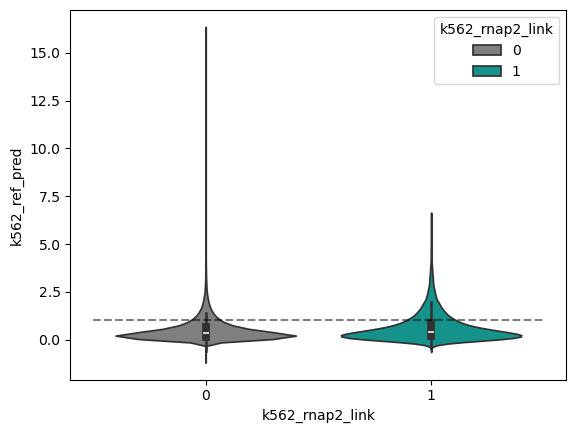

In [18]:
# plot k562 rnap2 linkage vs. ref activity
sns.violinplot(
    data = all_mean_preds,
    x='k562_rnap2_link',
    y='k562_ref_pred',
    hue='k562_rnap2_link',
    palette=colorPal
)
plt.hlines(y=1, xmin=-0.5, xmax=1.5, linestyles='dashed', color='k', alpha=0.5)

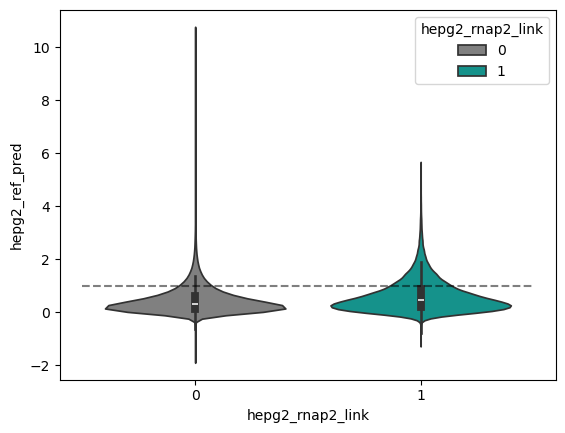

In [19]:
# plot hepg2 rnap2 linkage vs. ref activity
sns.violinplot(
    data = all_mean_preds,
    x='hepg2_rnap2_link',
    y='hepg2_ref_pred',
    hue='hepg2_rnap2_link',
    palette=colorPal
)
plt.hlines(y=1, xmin=-0.5, xmax=1.5, linestyles='dashed', color='k', alpha=0.5)

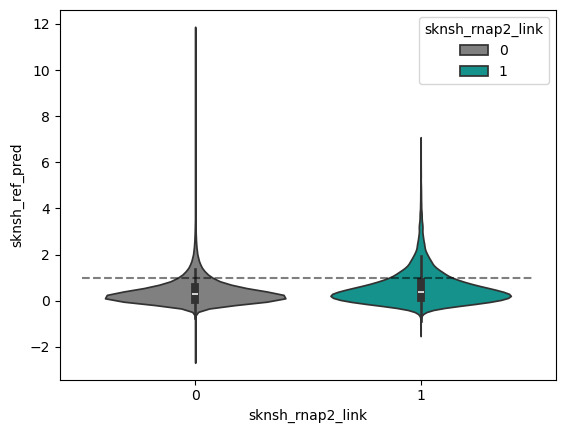

In [20]:
# plot sknsh rnap2 linkage vs. ref activity
sns.violinplot(
    data = all_mean_preds,
    x='sknsh_rnap2_link',
    y='sknsh_ref_pred',
    hue='sknsh_rnap2_link',
    palette=colorPal
)
plt.hlines(y=1, xmin=-0.5, xmax=1.5, linestyles='dashed', color='k', alpha=0.5)

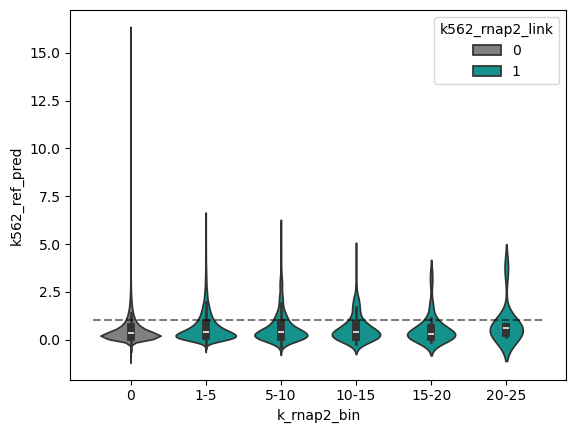

In [21]:
# check how bin affects activity
# plot k562 rnap2 linkage vs. ref activity
sns.violinplot(
    data = all_mean_preds,
    x='k_rnap2_bin',
    y='k562_ref_pred',
    hue='k562_rnap2_link',
    palette=colorPal
)
plt.hlines(y=1, xmin=-0.5, xmax=5.5, linestyles='dashed', color='k', alpha=0.5)

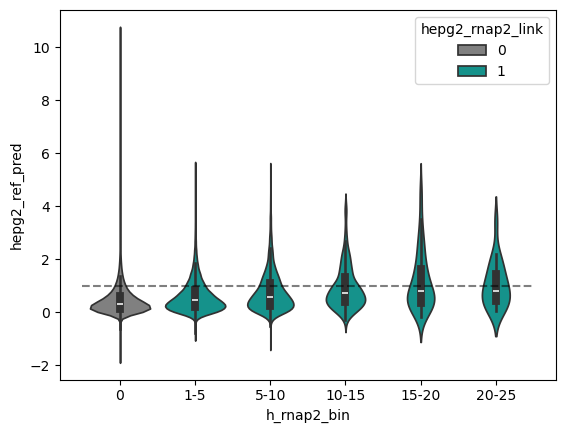

In [22]:
# check how bin affects activity
# plot hepg2 rnap2 linkage vs. ref activity
sns.violinplot(
    data = all_mean_preds,
    x='h_rnap2_bin',
    y='hepg2_ref_pred',
    hue='hepg2_rnap2_link',
    palette=colorPal
)
plt.hlines(y=1, xmin=-0.5, xmax=5.5, linestyles='dashed', color='k', alpha=0.5)

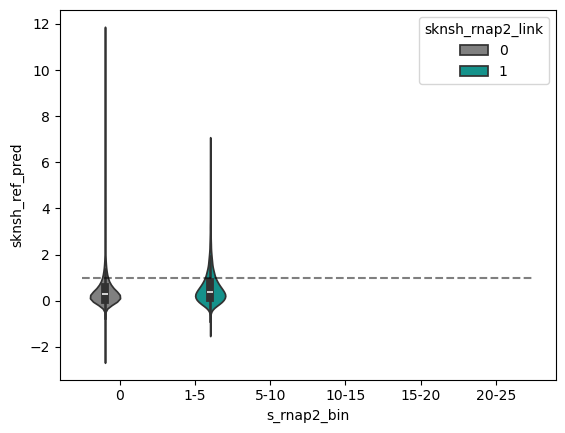

In [23]:
# check how bin affects activity
# plot sknsh rnap2 linkage vs. ref activity
sns.violinplot(
    data = all_mean_preds,
    x='s_rnap2_bin',
    y='sknsh_ref_pred',
    hue='sknsh_rnap2_link',
    palette=colorPal
)
plt.hlines(y=1, xmin=-0.5, xmax=5.5, linestyles='dashed', color='k', alpha=0.5)

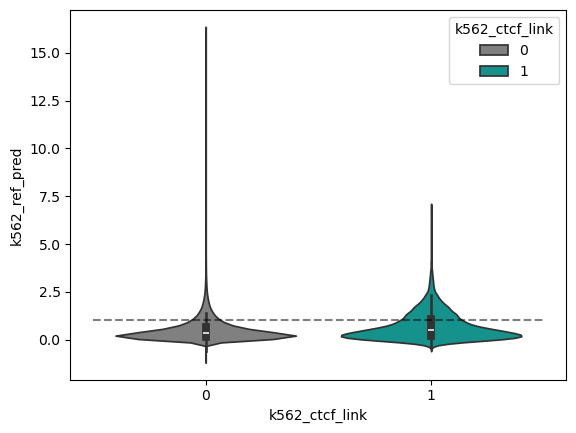

In [24]:
# plot k562 ctcf-chia pet linkage vs. ref activity
sns.violinplot(
    data = all_mean_preds,
    x='k562_ctcf_link',
    y='k562_ref_pred',
    hue='k562_ctcf_link',
    palette=colorPal
)
plt.hlines(y=1, xmin=-0.5, xmax=1.5, linestyles='dashed', color='k', alpha=0.5)

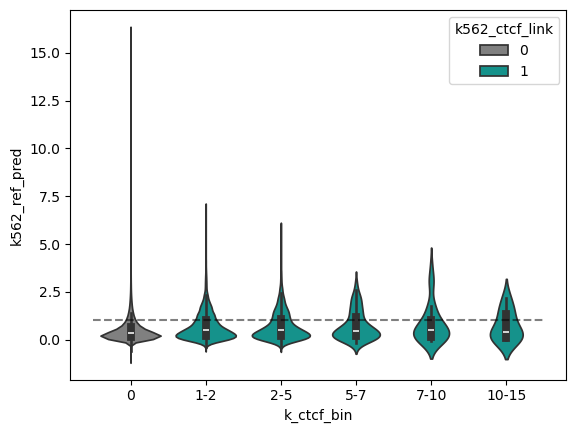

In [33]:
# check how bin affects activity
# plot k562 ctcf linkage vs. ref activity
sns.violinplot(
    data = all_mean_preds,
    x='k_ctcf_bin',
    y='k562_ref_pred',
    hue='k562_ctcf_link',
    palette=colorPal
)
plt.hlines(y=1, xmin=-0.5, xmax=5.5, linestyles='dashed', color='k', alpha=0.5)

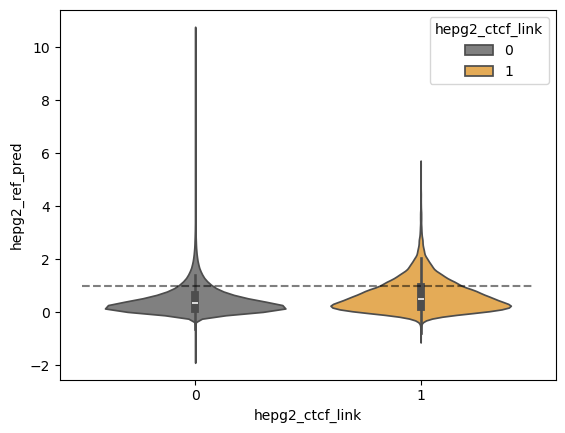

In [27]:
sns.violinplot(
    data = all_mean_preds,
    x='hepg2_ctcf_link',
    y='hepg2_ref_pred',
    hue='hepg2_ctcf_link',
    palette=colorPal
)
plt.hlines(y=1, xmin=-0.5, xmax=1.5, linestyles='dashed', color='k', alpha=0.5)

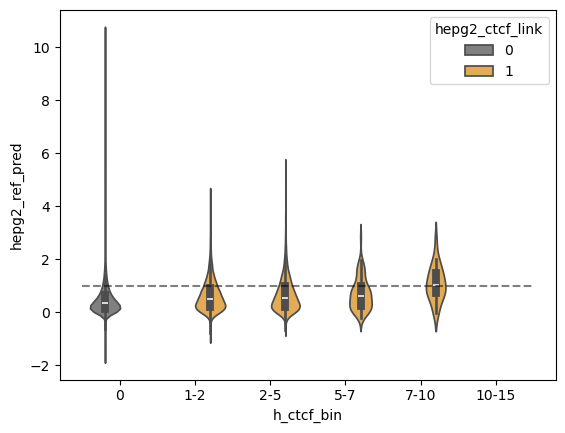

In [35]:
# check how bin affects activity
# plot hepg2 rnap2 linkage vs. ref activity
sns.violinplot(
    data = all_mean_preds,
    x='h_ctcf_bin',
    y='hepg2_ref_pred',
    hue='hepg2_ctcf_link',
    palette=colorPal
)
plt.hlines(y=1, xmin=-0.5, xmax=5.5, linestyles='dashed', color='k', alpha=0.5)

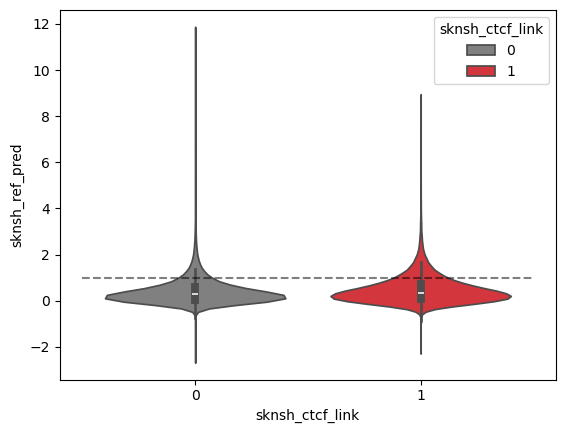

In [37]:
sns.violinplot(
    data = all_mean_preds,
    x='sknsh_ctcf_link',
    y='sknsh_ref_pred',
    hue='sknsh_ctcf_link',
    palette=colorPal
)
plt.hlines(y=1, xmin=-0.5, xmax=1.5, linestyles='dashed', color='k', alpha=0.5)

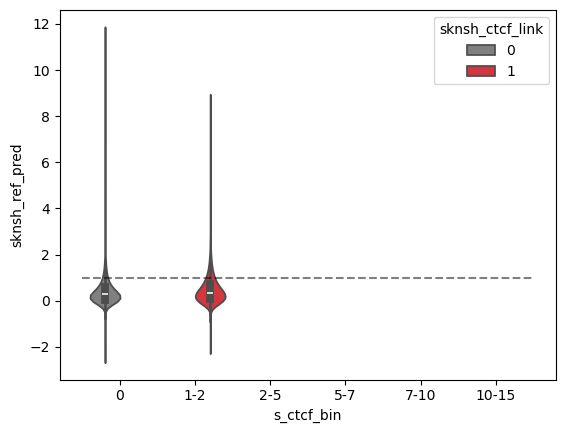

In [38]:
sns.violinplot(
    data = all_mean_preds,
    x='s_ctcf_bin',
    y='sknsh_ref_pred',
    hue='sknsh_ctcf_link',
    palette=colorPal
)
plt.hlines(y=1, xmin=-0.5, xmax=5.5, linestyles='dashed', color='k', alpha=0.5)

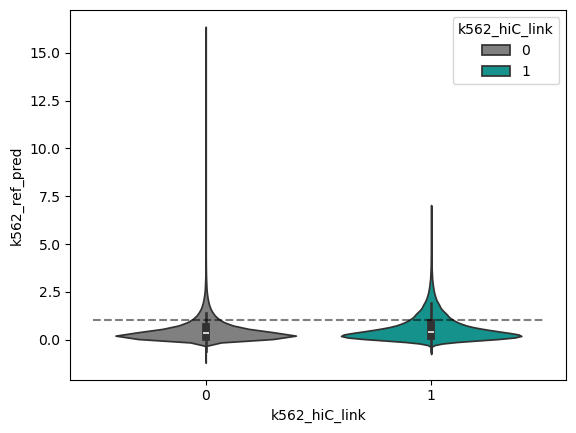

In [40]:
# plot k562 hic pet linkage vs. ref activity
sns.violinplot(
    data = all_mean_preds,
    x='k562_hiC_link',
    y='k562_ref_pred',
    hue='k562_hiC_link',
    palette=colorPal
)
plt.hlines(y=1, xmin=-0.5, xmax=1.5, linestyles='dashed', color='k', alpha=0.5)

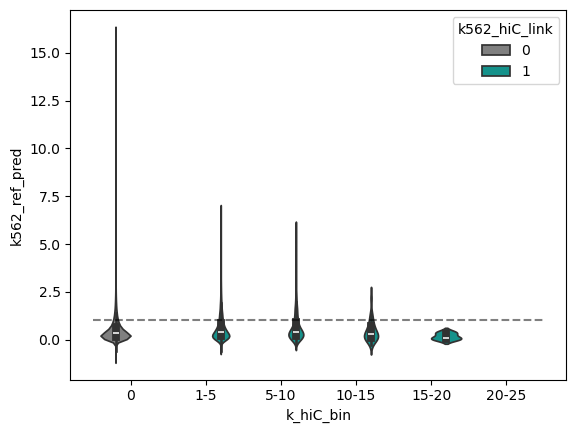

In [43]:
# plot k562 hic pet linkage vs. ref activity
sns.violinplot(
    data = all_mean_preds,
    x='k_hiC_bin',
    y='k562_ref_pred',
    hue='k562_hiC_link',
    palette=colorPal
)
plt.hlines(y=1, xmin=-0.5, xmax=5.5, linestyles='dashed', color='k', alpha=0.5)

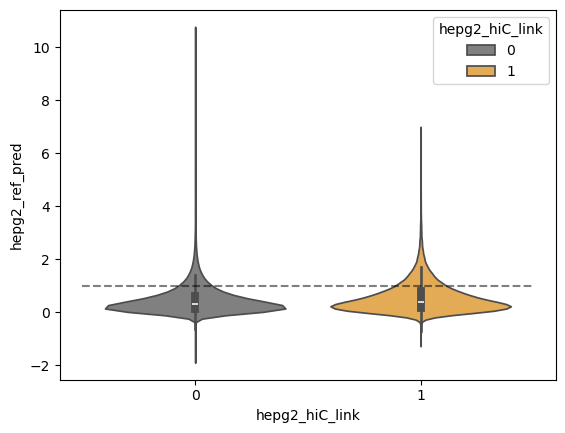

In [45]:
# plot hepg2 hic pet linkage vs. ref activity
sns.violinplot(
    data = all_mean_preds,
    x='hepg2_hiC_link',
    y='hepg2_ref_pred',
    hue='hepg2_hiC_link',
    palette=colorPal
)
plt.hlines(y=1, xmin=-0.5, xmax=1.5, linestyles='dashed', color='k', alpha=0.5)

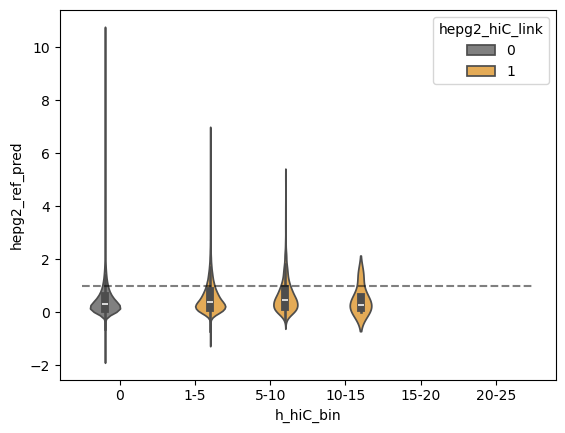

In [46]:
# plot hepg hic pet linkage vs. ref activity
sns.violinplot(
    data = all_mean_preds,
    x='h_hiC_bin',
    y='hepg2_ref_pred',
    hue='hepg2_hiC_link',
    palette=colorPal
)
plt.hlines(y=1, xmin=-0.5, xmax=5.5, linestyles='dashed', color='k', alpha=0.5)

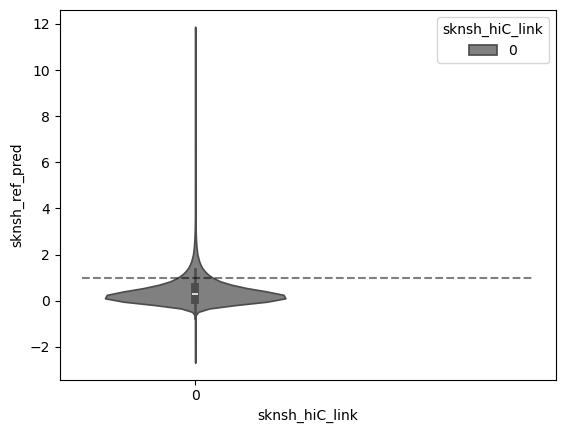

In [48]:
# plot hepg2 hic pet linkage vs. ref activity
sns.violinplot(
    data = all_mean_preds,
    x='sknsh_hiC_link',
    y='sknsh_ref_pred',
    hue='sknsh_hiC_link',
    palette=colorPal
)
plt.hlines(y=1, xmin=-0.5, xmax=1.5, linestyles='dashed', color='k', alpha=0.5)